# Ejercicio 02 (U01.LAB03): ensambles, reducción dimensional y Green AI

Se amplía el mismo problema del Ejercicio 01 (HCV Data, detección de enfermedad hepática a partir de una analítica de sangre) con ensambles, reducción dimensional, mediciones repetidas y una decisión sobre la frontera de Pareto.

Ejercicio académico. Los resultados **no constituyen un diagnóstico médico**.

In [1]:
# VS Code ejecuta el notebook desde notebooks/; se trabaja desde la raíz del proyecto
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, "src")
print(Path.cwd())

C:\Users\roque.ventura\Desktop\Desktop\Maestria UASD\Materias\Ciencia de datos II\Ejercicio 02


## 1. Protocolo congelado

Se reutiliza el protocolo del LAB02 sin cambios:

- **Dataset:** HCV Data (UCI, CC BY 4.0, DOI 10.24432/C5D612), descargado en `data/raw/dataset.csv`.
- **Target:** `hepatopatia`: `si` = hepatitis, fibrosis o cirrosis; `no` = donante sano.
- **Exclusiones:** las filas `0s=suspect Blood Donor` (etiqueta incierta), `Unnamed: 0` (identificador ordenado por clase, fuga) y `Category` (fuente del target).
- **Partición:** 80/20 estratificada con `random_state=42`, la misma del Ejercicio 01. No se cambia para favorecer a ningún modelo.
- **Métrica principal:** F1-macro.
- **Clase prioritaria:** `si` (enfermo). El error más costoso es el falso negativo.
- **Prueba:** el conjunto de prueba no se usa para ajustar nada; solo se evalúa sobre él al cerrar cada medición.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from inf8239_u01.data import download_csv

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00571/hcvdat0.csv"
if not Path("data/raw/dataset.csv").exists():
    download_csv(URL)

df = pd.read_csv("data/raw/dataset.csv")
df = df[df["Category"] != "0s=suspect Blood Donor"].copy()
df["hepatopatia"] = df["Category"].str[0].map({"0": "no", "1": "si", "2": "si", "3": "si"})

TARGET = "hepatopatia"
DROP_COLUMNS = ["Unnamed: 0", "Category"]
X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.20, random_state=42, stratify=y)
print(X.shape, Xtr.shape, Xte.shape)
print(yte.value_counts())

(608, 12) (486, 12) (122, 12)
hepatopatia
no    107
si     15
Name: count, dtype: int64


### Preprocesamiento

Es el mismo del Ejercicio 01 (imputación por mediana y estandarización para las variables numéricas; imputación por moda y one-hot para `Sex`). `HistGradientBoostingClassifier` necesita salida densa, así que el `OneHotEncoder` usa `sparse_output=False`. Se mide el costo de memoria de la matriz resultante.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)])
Z = preprocess.fit_transform(Xtr)
print("Matriz densa de entrenamiento:", Z.shape, "| memoria:", round(Z.nbytes / 1024, 1), "KB")

Matriz densa de entrenamiento: (486, 13) | memoria: 49.4 KB


## 2. Catálogo de modelos

In [4]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
 "logistic": Pipeline([("prep",preprocess),("model",LogisticRegression(max_iter=2000))]),
 "svm_c1": Pipeline([("prep",preprocess),("model",SVC(C=1,probability=True,random_state=42))]),
 "svm_c10": Pipeline([("prep",preprocess),("model",SVC(C=10,probability=True,random_state=42))]),
 "rf_100": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1))]),
 "rf_300": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1))]),
 "boost": Pipeline([("prep",preprocess),("model",HistGradientBoostingClassifier(max_depth=6,random_state=42))])
}

## 3. Medir tres veces

In [5]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

Path("reports/models").mkdir(parents=True,exist_ok=True)
rows=[]
for name,model in models.items():
    fit_times=[]
    for repetition in range(3):
        start=perf_counter(); model.fit(Xtr,ytr)
        fit_times.append(perf_counter()-start)
    start=perf_counter(); pred=model.predict(Xte)
    predict_ms=(perf_counter()-start)*1000
    path=Path("reports/models")/f"{name}.joblib"
    joblib.dump(model,path)
    rows.append({"model":name,"f1_macro":f1_score(yte,pred,average="macro"),
      "recall_macro":recall_score(yte,pred,average="macro"),
      "fit_median_s":np.median(fit_times),"predict_ms":predict_ms,
      "size_kb":path.stat().st_size/1024})
results=pd.DataFrame(rows)
results.sort_values("f1_macro",ascending=False)

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
5,boost,0.959656,0.933333,0.282422,24.5229,181.642578
3,rf_100,0.937532,0.900000,0.188274,32.1324,333.838867
4,rf_300,0.937532,0.900000,0.797554,93.4268,984.151367
0,logistic,0.913903,0.866667,0.015588,4.0651,4.525391
2,svm_c10,0.902165,0.890654,0.024922,5.1921,17.193359
1,svm_c1,0.844018,0.795327,0.025207,5.4877,18.162109


## 4. Comparar con y sin PCA

El dataset incluye una variable categórica (`Sex`), así que el PCA se aplica solamente al bloque numérico (después de imputar y estandarizar) y `Sex` pasa por el one-hot sin reducir. La SVM con PCA se compara con `svm_c1`, que es la misma SVM sin PCA, medida de la misma forma.

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_pca_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scale", StandardScaler()),
                         ("pca", PCA(n_components=.95, random_state=42))])
svm_pca = Pipeline([
 ("prep", ColumnTransformer([("num", num_pca_pipe, num_cols), ("cat", cat_pipe, cat_cols)])),
 ("model", SVC(C=1, probability=True, random_state=42))
])
svm_pca.fit(Xtr,ytr)
print("Componentes:", svm_pca.named_steps["prep"].named_transformers_["num"].named_steps["pca"].n_components_,
      "de", len(num_cols), "variables numéricas")

fit_times=[]
for repetition in range(3):
    start=perf_counter(); svm_pca.fit(Xtr,ytr)
    fit_times.append(perf_counter()-start)
start=perf_counter(); pred=svm_pca.predict(Xte)
predict_ms=(perf_counter()-start)*1000
path=Path("reports/models")/"svm_pca.joblib"
joblib.dump(svm_pca,path)
pca_row={"model":"svm_pca","f1_macro":f1_score(yte,pred,average="macro"),
  "recall_macro":recall_score(yte,pred,average="macro"),
  "fit_median_s":np.median(fit_times),"predict_ms":predict_ms,
  "size_kb":path.stat().st_size/1024}
pd.concat([results[results.model=="svm_c1"], pd.DataFrame([pca_row])], ignore_index=True)

Componentes: 10 de 11 variables numéricas


,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
0,svm_c1,0.844018,0.795327,0.025207,5.4877,18.162109
1,svm_pca,0.844018,0.795327,0.050057,10.6936,19.349609


**Resultado:** para conservar el 95 % de la varianza, el PCA necesita 10 de las 11 variables numéricas, así que casi no reduce la dimensión. `svm_pca` obtiene el mismo F1-macro que `svm_c1` (0.844), tarda el doble en ajustarse y ocupa un poco más. En este dataset el PCA no aporta beneficio.

## 5. Dos mapas t-SNE

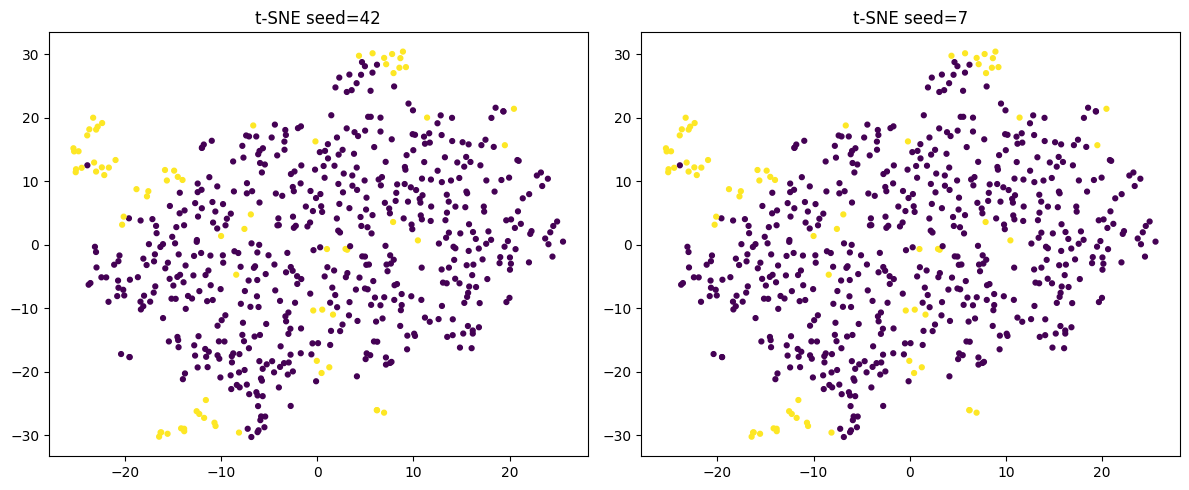

In [7]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_num=X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample=X_num.sample(min(1000,len(X_num)),random_state=42)
y_sample=y.loc[sample.index]
scaled=StandardScaler().fit_transform(sample)
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,seed in zip(axes,[42,7]):
    emb=TSNE(n_components=2,perplexity=30,random_state=seed,init="pca",learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:,0],emb[:,1],c=pd.Categorical(y_sample).codes,s=12,cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")
plt.tight_layout();plt.savefig("reports/tsne_two_seeds.png",dpi=160)

**Qué permanece y qué cambia.** Morado = `no` (donante) y amarillo = `si` (enfermo). Con `init="pca"`, los dos mapas son prácticamente iguales: se mantienen la forma general y la posición de los grupos, y solo cambian ligeramente algunos puntos aislados. En ambos, la mayoría de los enfermos forma pequeños grupos en la periferia, pero algunos quedan mezclados entre los donantes, lo que es coherente con los falsos negativos de los modelos. La separación visual no demuestra causalidad ni valida por sí sola un clasificador.

## 6. Frontera de Pareto

In [8]:
from inf8239_u01.green import pareto_flags

results["is_pareto"]=pareto_flags(results)
results.to_csv("reports/green_ai_results.csv",index=False)
results.sort_values(["is_pareto","f1_macro"],ascending=[False,False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
5,boost,0.959656,0.933333,0.282422,24.5229,181.642578,True
3,rf_100,0.937532,0.900000,0.188274,32.1324,333.838867,True
0,logistic,0.913903,0.866667,0.015588,4.0651,4.525391,True
4,rf_300,0.937532,0.900000,0.797554,93.4268,984.151367,False
2,svm_c10,0.902165,0.890654,0.024922,5.1921,17.193359,False
1,svm_c1,0.844018,0.795327,0.025207,5.4877,18.162109,False


## 7. Dibujar y cuantificar la decisión

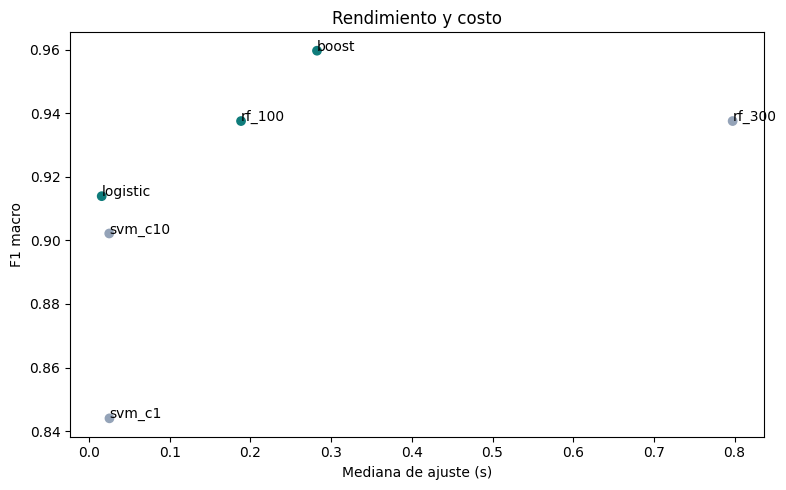

In [9]:
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(results.fit_median_s,results.f1_macro,c=results.is_pareto.map({True:"#0f7c7b",False:"#94a3b8"}))
for _,r in results.iterrows(): ax.annotate(r.model,(r.fit_median_s,r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)",ylabel="F1 macro",title="Rendimiento y costo")
plt.tight_layout();plt.savefig("reports/pareto.png",dpi=160)

In [10]:
# Cuantificación de la decisión: máximo F1 frente a cada modelo de la frontera de Pareto
best = results.loc[results.f1_macro.idxmax()]
print("Máximo F1-macro:", best.model, round(best.f1_macro, 4),
      "| ajuste", round(best.fit_median_s, 4), "s | tamaño", round(best.size_kb, 1), "KB")
comparison = []
for _, r in results[results.is_pareto].iterrows():
    pred = models[r.model].predict(Xte)
    comparison.append({"model": r.model, "f1_macro": r.f1_macro,
                       "recall_si": recall_score(yte, pred, pos_label="si"),
                       "diferencia_f1": best.f1_macro - r.f1_macro,
                       "ahorro_tiempo_pct": (best.fit_median_s - r.fit_median_s) / best.fit_median_s * 100,
                       "diferencia_tamano_kb": best.size_kb - r.size_kb})
pd.DataFrame(comparison).sort_values("f1_macro", ascending=False).round(4)

Máximo F1-macro: boost 0.9597 | ajuste 0.2824 s | tamaño 181.6 KB


,model,f1_macro,recall_si,diferencia_f1,ahorro_tiempo_pct,diferencia_tamano_kb
2,boost,0.9597,0.8667,0.0000,0.0000,0.0000
1,rf_100,0.9375,0.8000,0.0221,33.3358,-152.1963
0,logistic,0.9139,0.7333,0.0458,94.4805,177.1172


**Decisión.**

- **Máximo F1-macro:** `boost`, 0.9597, con recall de `si` de 0.867 (13 de 15 enfermos), 0.282 s de ajuste y 181.6 KB.
- **Alternativa más eficiente de la frontera:** `logistic`, con 0.9139. La diferencia de F1 es de 0.0458, ahorra el 94.5 % del tiempo de ajuste y ocupa 177.1 KB menos, pero detecta 11 de 15 enfermos.
- **Modelo seleccionado:** `boost`. El ahorro de la logística son unos 0.27 s por entrenamiento, y a cambio deja escapar a dos enfermos más, que es el error prioritario del protocolo.

La argumentación completa está en `reports/conclusion.md`. Las cifras corresponden a esta ejecución.

## 8. Entorno de medición

In [11]:
import platform,sys,sklearn
print("Python",sys.version)
print("Sistema",platform.platform())
print("Procesador",platform.processor())
print("scikit-learn",sklearn.__version__)

Python 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Sistema Windows-10-10.0.26200-SP0
Procesador Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
scikit-learn 1.7.2


El tiempo es contextual: depende de este equipo y cambia entre ejecuciones. No se presenta como consumo energético y no se midió energía ni CO2. `platform` muestra "Windows-10", pero la compilación 26200 corresponde a Windows 11.